# Model Training Results (train_text_classification_bert.py)

In [1]:
from IPython.display import Image, display

In [13]:
with open("./outputs/train_text_classification_bert/log.log", "r") as f:
    lines = f.readlines()
print(*lines[-11:-2])

              precision    recall  f1-score   support
 
            0       0.92      0.94      0.93      6250
            1       0.94      0.91      0.93      6250
 
     accuracy                           0.93     12500
    macro avg       0.93      0.93      0.93     12500
 weighted avg       0.93      0.93      0.93     12500
 



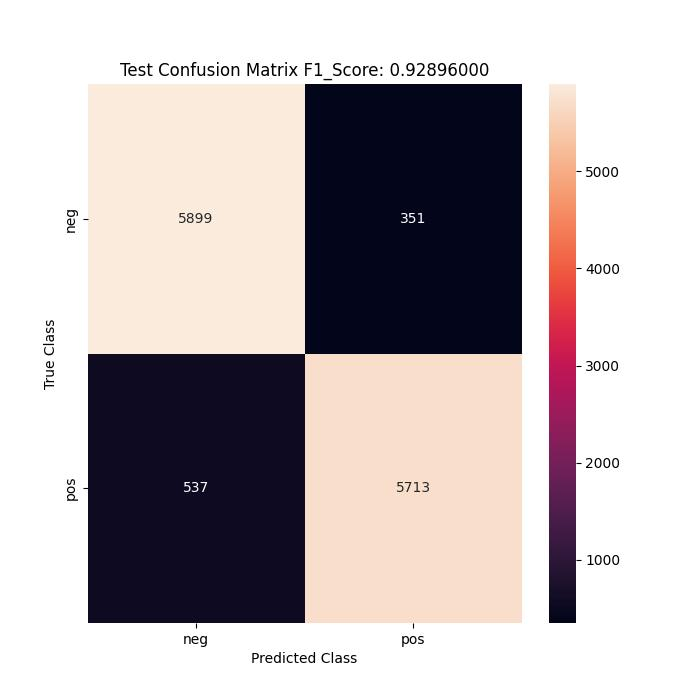

In [2]:
display(Image("./outputs/train_text_classification_bert/best_model.jpg"))

### Text
* LayerIntegratedGradients

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,3,5'

import numpy as np
from tqdm import tqdm
import pickle as pkl
import torch
from torch.utils.data import TensorDataset, DataLoader
import captum
from pathlib import Path

from transformers import AutoTokenizer
from captum.attr import LayerIntegratedGradients, visualization


In [3]:
def pad_or_truncate(arr, target_len, pad_value=0):
    dtype = np.int16
    arr = np.asarray(arr, dtype = dtype)
    if len(arr) > target_len:
        # truncate
        return arr[:target_len]
    elif len(arr) < target_len:
        # padding
        pad_width = target_len - len(arr)
        return np.pad(arr, (0, pad_width), mode='constant', constant_values=dtype(pad_value))
    else:
        return arr
    
def forward_func(input_ids, model):
    outputs = model(input_ids=input_ids)
    return outputs.logits

In [4]:
CURRUENT_PATH = Path.cwd()
OUTPUT_PATH = CURRUENT_PATH / 'outputs' /'train_text_classification_bert'

In [5]:
with open(f'{CURRUENT_PATH}/imdb_preprocessed.pkl', 'rb') as f:
    train_x, train_y, valid_x, valid_y, test_x, test_y = pkl.load(f)


In [6]:
GPU_PARALLEL = True
model = torch.load(OUTPUT_PATH / 'best_model.pt')

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
model.to(device)
if GPU_PARALLEL:
    model = torch.nn.DataParallel(model)
model.eval()

DataParallel(
  (module): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, 

In [7]:
model.module.bert.embeddings if GPU_PARALLEL else model.bert.embeddings

BertEmbeddings(
  (word_embeddings): Embedding(30522, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [8]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [9]:
lig = LayerIntegratedGradients(
    forward_func,
    model.module.bert.embeddings if GPU_PARALLEL else model.bert.embeddings,
    device_ids=model.device_ids
    )
baseline = torch.zeros_like(torch.from_numpy(test_x).to(device, dtype=torch.long))
input_ids = torch.from_numpy(test_x)
targets = torch.from_numpy(test_y)

In [10]:
test_dataset = TensorDataset(input_ids, targets)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [11]:
# 100%|██████████| 782/782 [1:55:19<00:00,  8.85s/it]

all_attr, all_delta = [], []
for x, y in tqdm(test_loader):
    x = x.to(device, dtype=torch.long)
    y = y.tolist()
    baseline = torch.zeros_like(x)
    attributions, delta = lig.attribute(
        inputs=x,
        baselines=baseline,
        additional_forward_args=(model,),
        target=y,  # 보고 싶은 클래스 index
        n_steps=25,
        internal_batch_size=64,
        return_convergence_delta=True
    )
    all_attr.append(attributions.detach().cpu())
    all_delta.append(delta.detach().cpu())
all_attr = torch.cat(all_attr, dim=0)
all_delta = torch.cat(all_delta, dim=0)

  0%|          | 0/196 [00:00<?, ?it/s]We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
100%|██████████| 196/196 [42:48<00:00, 13.10s/it]


In [12]:
with open(CURRUENT_PATH / 'imdb_test_x_LayerIntergratedGradient.pkl', 'wb') as f:
    pkl.dump([all_attr, all_delta], f, protocol=pkl.HIGHEST_PROTOCOL)

# with open(CURRUENT_PATH / 'imdb_test_x_LayerIntergratedGradient.pkl', 'rb') as f:
#     all_attr, all_delta = pkl.load(f)

In [13]:
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

pred_probs, pred_labels = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device, dtype=torch.long)
        y = y.tolist()
        probs = model(x).logits
        pred_label = torch.argmax(probs, dim=1).detach().cpu().tolist()
        
        pred_probs.extend(probs.detach().cpu().tolist())
        pred_labels.extend(pred_label)

100%|██████████| 196/196 [00:46<00:00,  4.20it/s]


In [14]:
pred_probs = torch.softmax(torch.Tensor(pred_probs), dim=-1)
pred_labels = torch.Tensor(pred_labels)

In [15]:
print(len(all_attr), len(all_delta), len(pred_probs), len(pred_labels),len(test_x), len(test_y))

12500 12500 12500 12500 12500 12500


In [16]:
# https://github.com/meta-pytorch/captum/blob/master/captum/attr/_utils/visualization.py
# word_attributions: Tensor,
# pred_prob: float,
# pred_class: int,
# true_class: int,
# attr_class: int,
# attr_score: float,
# raw_input_ids: List[str],
# convergence_score: float,

viz_results = []
for attr, delta, pred_prob, pred_label, x, y in zip(all_attr, all_delta.tolist(), pred_probs.tolist(), pred_labels.tolist(), test_x, test_y):
    pred_label = int(pred_label)
    viz = visualization.VisualizationDataRecord(
        word_attributions = attr.sum(dim=1),
        pred_prob = pred_prob[pred_label],
        pred_class = pred_label,
        true_class = y,
        attr_class = pred_label,
        attr_score = attr.sum().item(),
        raw_input_ids = [tokenizer.decode(i) for i in x],
        convergence_score = delta
    )
    viz_results.append(viz)

In [17]:
_ = visualization.visualize_text(viz_results[:10])